In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')

# Clean the data (same as Task 2)
df['age'] = df['age'].fillna(df['age'].median())
df = df.drop(columns=['deck'])
df = df.dropna(subset=['embarked', 'embark_town'])

# Feature engineering (same as Task 2)
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 80],
                          labels=['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (60+)'])
df['family_size'] = df['sibsp'] + df['parch'] + 1

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_group,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult (19-35),2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult (36-60),2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult (19-35),1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Young Adult (19-35),2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Young Adult (19-35),1


In [5]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

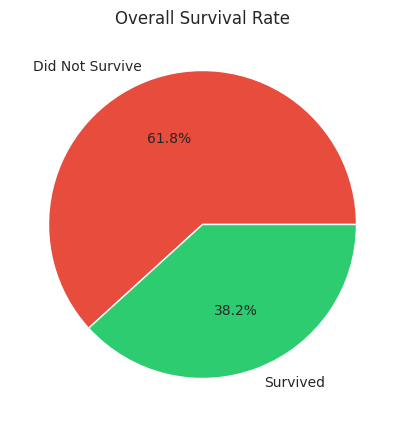

In [6]:
plt.figure()
df['survived'].value_counts().plot(kind='pie', labels=['Did Not Survive', 'Survived'],
                                     autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'])
plt.title('Overall Survival Rate')
plt.ylabel('')
plt.show()

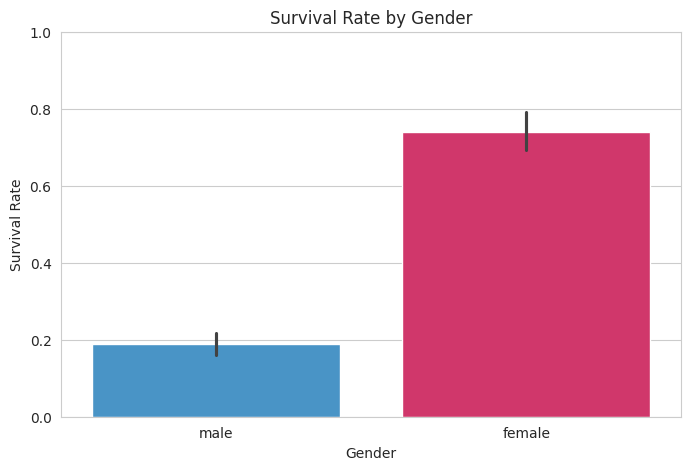

In [7]:
plt.figure()
sns.barplot(data=df, x='sex', y='survived', hue='sex', palette=['#3498db', '#e91e63'], legend=False)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

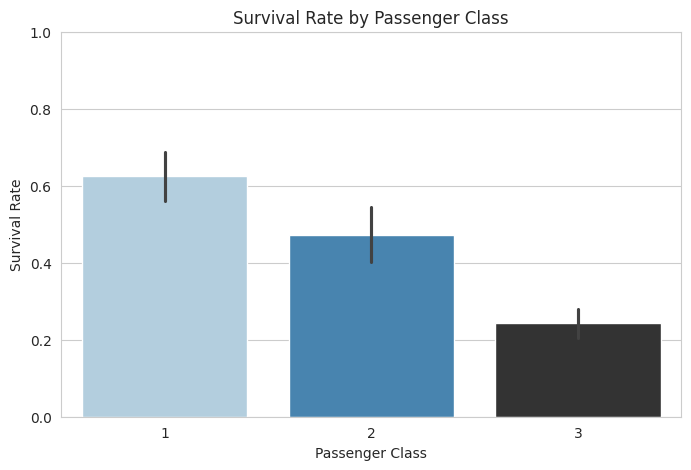

In [8]:
plt.figure()
sns.barplot(data=df, x='pclass', y='survived', hue='pclass', palette='Blues_d', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

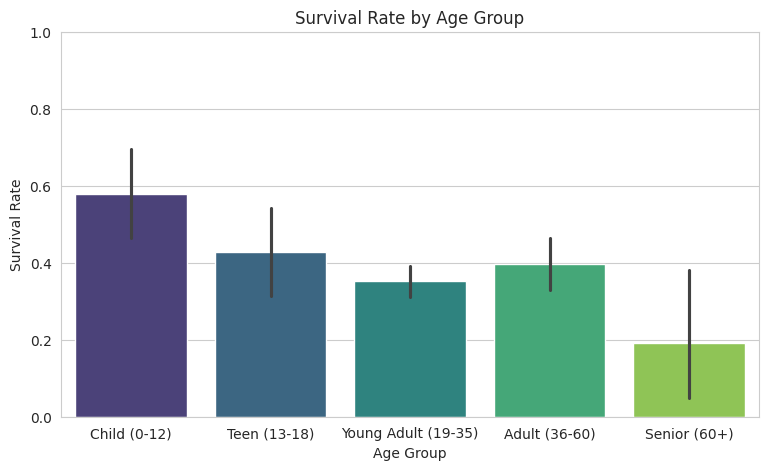

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='age_group', y='survived', hue='age_group', palette='viridis', legend=False)
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

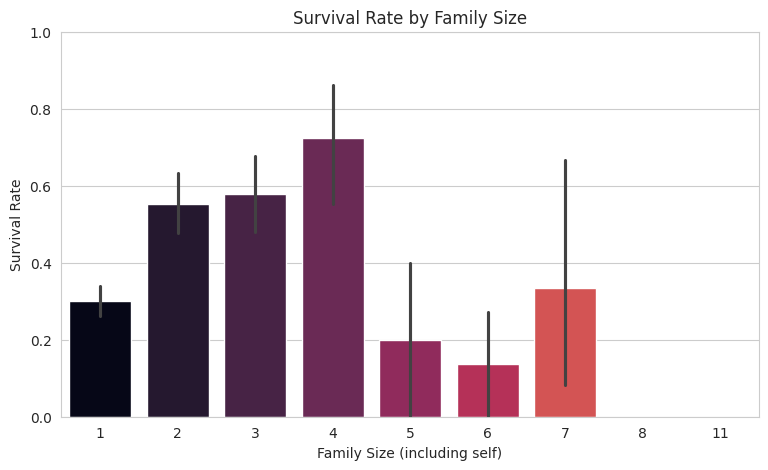

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='family_size', y='survived', hue='family_size', palette='rocket', legend=False)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size (including self)')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

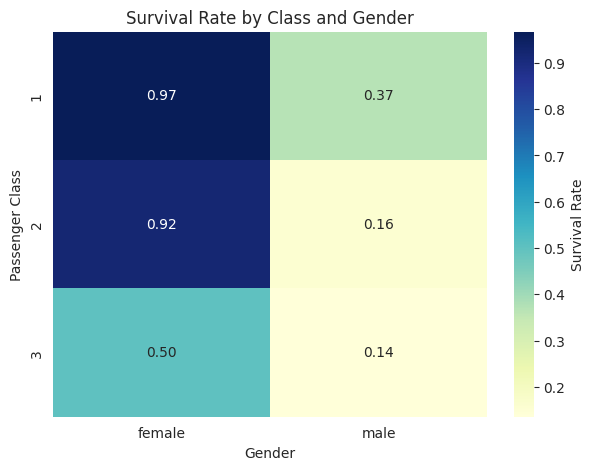

In [11]:
plt.figure(figsize=(7, 5))
pivot = df.pivot_table(values='survived', index='pclass', columns='sex', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Class')
plt.show()